# t-SNE on raw trajectories

In [1]:
import numpy as np
data = np.load("../../../simulated_data/001-gridrobot/data/gridrobot_1960.npz")
all_trajs = data["trajs"]
all_feats = data["features"]

In [2]:
from sklearn import manifold
from matplotlib import ticker
import matplotlib.pyplot as plt

t_sne = manifold.TSNE(
    n_components=2,
    perplexity=30,
    init="random",
    max_iter=250,
    random_state=0,
)

def plot_2d(points, points_color, title):
    fig, ax = plt.subplots(figsize=(3, 3), facecolor="white", constrained_layout=True)
    fig.suptitle(title, size=16)
    add_2d_scatter(ax, points, points_color)
    plt.show()


def add_2d_scatter(ax, points, points_color, title=None):
    x, y = points.T
    ax.scatter(x, y, c=points_color, s=50, alpha=0.8)
    ax.set_title(title)
    ax.xaxis.set_major_formatter(ticker.NullFormatter())
    ax.yaxis.set_major_formatter(ticker.NullFormatter())

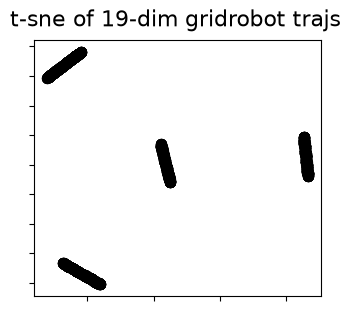

In [3]:
trajs_t_sne = t_sne.fit_transform(all_trajs)
plot_2d(trajs_t_sne, "black", "t-sne of 19-dim gridrobot trajs")


In [4]:
from sklearn.manifold import TSNE
import plotly.express as px

# t_sne = TSNE(
#     n_components=2,
#     random_state=0,
# )
# trajs_t_sne = t_sne.fit_transform(all_trajs)

fig = px.scatter(
    trajs_t_sne , x=0, y=1
)
fig.show()

------ Agent MDP ------
num X :  5
num Y :  5
obstacles :  0
-----------------------


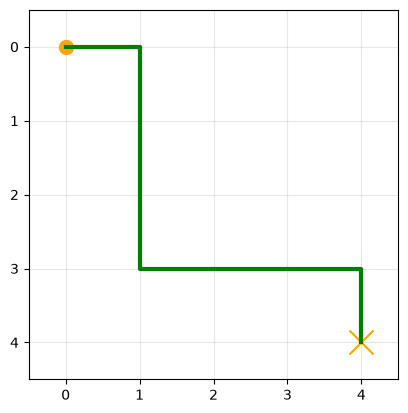

In [5]:
import sys
sys.path.insert(0, '../../../simulated_data/001-gridrobot/')
from gridrobot import Gridrobot
    
config = {
    "X": 5,
    "Y": 5,
    "obstacles": [],
    "starts": [[0, 0], [0, 4], [4, 0], [4, 4]],
    "goals": [[4, 4], [4, 0], [0, 4], [0, 0]],
    "features": ["computer_dist", "joint_up"],
    "thetas": [[ -10.0, -10.0 ],
              [ 0.0, -10.0 ],
              [ 10.0, -10.0 ],
              [ -10.0, 0.0 ],
              [ 10.0, 0.0 ],
              [ -10.0, 10.0 ],
              [ 0.0, 10.0 ],
              [ 10.0, 10.0 ]
    ],
    "beta": 10.0,
    "feature_scaling": "normalize",
    "train_test_split": 0.8
}
env = Gridrobot(config["X"], config["Y"], config["obstacles"], config["starts"], config["goals"])
env.visualize_one_traj(all_trajs[0])

In [ ]:
import plotly.graph_objects as go
from ipywidgets import Output, HBox
from IPython.display import clear_output
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# # t-SNE (same as before) — order is preserved, so row i <-> all_trajs[i]
# trajs_t_sne = TSNE(n_components=2, random_state=0).fit_transform(all_trajs)

# scatter as a FigureWidget so we can attach a hover callback
scatter = go.FigureWidget(
    data=[go.Scatter(
        x=trajs_t_sne[:, 0],
        y=trajs_t_sne[:, 1],
        mode="markers",
        marker=dict(size=8, opacity=0.7),
        customdata=list(range(len(all_trajs))),
        hovertemplate="traj %{customdata}<extra></extra>",
    )]
)
scatter.update_layout(width=500, height=500, title="t-SNE of trajectories")

# side panel where the trajectory gets drawn
out = Output()

def show_traj(trace, points, state):
    if not points.point_inds:
        return
    idx = points.point_inds[0]
    with out:
        clear_output(wait=True)          # replace the previous trajectory
        env.visualize_one_traj(all_trajs[idx])
        plt.show()

scatter.data[0].on_hover(show_traj)

HBox([scatter, out])                     # scatter on the left, trajectory on the right

    'data': [{'customdata': [0, 1, 2, ..., 1957, 1958, 1959],
              'hov…

4 distinct clusters, 1 per (start point, end point) pair (since trajectory always goes from one corner to the opposite corner)

# 

# feature vectors

In [18]:
import plotly.graph_objects as go
from ipywidgets import Output, HBox
from IPython.display import clear_output
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# # t-SNE (same as before) — order is preserved, so row i <-> all_trajs[i]
# trajs_t_sne = TSNE(n_components=2, random_state=0).fit_transform(all_trajs)

# scatter as a FigureWidget so we can attach a hover callback
scatter = go.FigureWidget(
    data=[go.Scatter(
        x=all_feats[:, 0],
        y=all_feats[:, 1],
        mode="markers",
        marker=dict(size=8, opacity=0.7),
        customdata=list(range(len(all_trajs))),
        hovertemplate="traj %{customdata}<extra></extra>",
    )]
)
scatter.update_layout(
    width=500, 
    height=500, 
    title="2D ground truth feature vectors",
    xaxis_title="laptop",
    yaxis_title="upright",
    )

# side panel where the trajectory gets drawn
out = Output()

def show_traj(trace, points, state):
    if not points.point_inds:
        return
    idx = points.point_inds[0]
    with out:
        clear_output(wait=True)          # replace the previous trajectory
        env.visualize_one_traj(all_trajs[idx])
        plt.show()

scatter.data[0].on_hover(show_traj)

HBox([scatter, out])                     # scatter on the left, trajectory on the right

    'data': [{'customdata': [0, 1, 2, ..., 1957, 1958, 1959],
              'hov…

# sirl embeds

# todos
plot ground truth feature vectors
plot SIRL vectors

use learned tversky sim to plot t-SNE